# Ablation 2 — Reference quality refinement

This notebook analyzes the **reference-quality ablation** for three motion families:

- **Worm1 → Theworm**
- **Lunges2 → Lunges3**
- **Facedown → Facedown1**

Goal:
1. Check whether a manually improved reference has lower reference jerk
2. Check whether it produces better clean-rollout tracking
3. Check whether it improves RL learning efficiency

Inputs:
- `logs/dsms_analysis/eval_plots/reference_quality.csv`
- `logs/dsms_analysis/eval_plots/all_trace_evaluation.csv`
- `logs/dsms_analysis/eval_plots/learning_efficiency.csv`

Outputs:
- `logs/dsms_analysis/ablation2_plots/`

This notebook is **pandas-free** and uses Python's built-in `csv` module.

In [1]:

from pathlib import Path
import csv
import math
import warnings

import numpy as np
import matplotlib.pyplot as plt


In [2]:

# ============================================================
# CONFIG
# ============================================================

PAIR_DEFS = [
    {
        "family": "Worm",
        "earlier": "Worm1",
        "later": "Theworm",
        "label": "Worm1 → Theworm",
        "preferred_training_config": "Standard",
    },
    {
        "family": "Lunges",
        "earlier": "Lunges2",
        "later": "Lunges3",
        "label": "Lunges2 → Lunges3",
        "preferred_training_config": "Standard",
    },
    {
        "family": "Facedown",
        "earlier": "Facedown",
        "later": "Facedown1",
        "label": "Facedown → Facedown1",
        "preferred_training_config": "Standard",
    },
]

CONDITIONS = ["GhostGUI", "DSMS"]

GG_COLOR = "#8A8A8A"
DSMS_COLOR = "#2F6BFF"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def find_repo_root():
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "logs" / "dsms_analysis").exists():
            return p
    raise FileNotFoundError(
        "Could not find repo root. Run this notebook from mjlab-trained/ "
        "or mjlab-trained/notebooks/."
    )

def read_csv(path):
    with open(path, newline="") as f:
        return list(csv.DictReader(f))

def to_float(value, default=np.nan):
    try:
        if value is None:
            return default
        s = str(value).strip()
        if s == "" or s.lower() == "nan":
            return default
        return float(s)
    except (TypeError, ValueError):
        return default

def is_finite(x):
    try:
        return np.isfinite(float(x))
    except (TypeError, ValueError):
        return False

def safe_percent_improvement(earlier, later, smaller_is_better=True):
    """
    Positive means the later reference is better.
    """
    earlier = to_float(earlier)
    later = to_float(later)

    if not is_finite(earlier) or not is_finite(later):
        return np.nan

    if earlier == 0:
        return np.nan

    if smaller_is_better:
        return 100.0 * (earlier - later) / earlier
    else:
        return 100.0 * (later - earlier) / abs(earlier)

ROOT = find_repo_root()
EVAL_DIR = ROOT / "logs" / "dsms_analysis" / "eval_plots"
OUT_DIR = ROOT / "logs" / "dsms_analysis" / "ablation2_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_CSV = EVAL_DIR / "reference_quality.csv"
TRACE_CSV = EVAL_DIR / "all_trace_evaluation.csv"
LEARNING_CSV = EVAL_DIR / "learning_efficiency.csv"

for p in [REFERENCE_CSV, TRACE_CSV, LEARNING_CSV]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

reference_rows = read_csv(REFERENCE_CSV)
trace_rows = read_csv(TRACE_CSV)
learning_rows = read_csv(LEARNING_CSV)

print("Repo root:", ROOT)
print("Evaluation dir:", EVAL_DIR)
print("Output dir:", OUT_DIR)
print("Pairs:", [p["label"] for p in PAIR_DEFS])


Repo root: /home/nathan/Desktop/mjlab-trained
Evaluation dir: /home/nathan/Desktop/mjlab-trained/logs/dsms_analysis/eval_plots
Output dir: /home/nathan/Desktop/mjlab-trained/logs/dsms_analysis/ablation2_plots
Pairs: ['Worm1 → Theworm', 'Lunges2 → Lunges3', 'Facedown → Facedown1']


In [3]:

# ============================================================
# ROW SELECTION HELPERS
# ============================================================

def choose_reference_row(rows, motion, condition, preferred_config=None):
    candidates = [
        r for r in rows
        if r.get("motion") == motion and r.get("condition") == condition
    ]
    if not candidates:
        return None

    # reference_quality.csv may not have training_config.
    if preferred_config is not None and "training_config" in candidates[0]:
        preferred = [
            r for r in candidates
            if r.get("training_config") == preferred_config
        ]
        if preferred:
            candidates = preferred

    candidates.sort(
        key=lambda r: (
            0 if is_finite(to_float(r.get("jerk_rms_rad_s3"))) else 1,
            -to_float(r.get("duration_s"), default=-1),
        )
    )
    return candidates[0]


def choose_trace_row(rows, motion, condition, preferred_config=None):
    candidates = [
        r for r in rows
        if r.get("motion") == motion and r.get("condition") == condition
    ]
    if not candidates:
        return None

    if preferred_config is not None:
        preferred = [
            r for r in candidates
            if r.get("training_config") == preferred_config
        ]
        if preferred:
            candidates = preferred

    # Prefer latest checkpoint.
    candidates.sort(
        key=lambda r: (
            -to_float(r.get("checkpoint_iteration"), default=-1),
            -to_float(r.get("reward_rate"), default=-1e9),
        )
    )
    return candidates[0]


def choose_learning_row(rows, motion, condition, preferred_config=None):
    candidates = [
        r for r in rows
        if r.get("motion") == motion and r.get("condition") == condition
    ]
    if not candidates:
        return None

    if preferred_config is not None:
        preferred = [
            r for r in candidates
            if r.get("training_config") == preferred_config
        ]
        if preferred:
            candidates = preferred

    # Prefer local TensorBoard rows over W&B duplicates, then latest run.
    source_rank = {"tensorboard": 0, "wandb": 1}

    candidates.sort(
        key=lambda r: (
            source_rank.get(r.get("source"), 9),
            -to_float(r.get("final_iteration"), default=-1),
        )
    )

    return candidates[0]


def summarize_pair(pair, condition):
    preferred = pair["preferred_training_config"]
    earlier_motion = pair["earlier"]
    later_motion = pair["later"]

    ref_early = choose_reference_row(
        reference_rows, earlier_motion, condition, preferred
    )
    ref_late = choose_reference_row(
        reference_rows, later_motion, condition, preferred
    )

    tr_early = choose_trace_row(
        trace_rows, earlier_motion, condition, preferred
    )
    tr_late = choose_trace_row(
        trace_rows, later_motion, condition, preferred
    )

    lrn_early = choose_learning_row(
        learning_rows, earlier_motion, condition, preferred
    )
    lrn_late = choose_learning_row(
        learning_rows, later_motion, condition, preferred
    )

    ref_early_jerk = (
        to_float(ref_early.get("jerk_rms_rad_s3")) if ref_early else np.nan
    )
    ref_late_jerk = (
        to_float(ref_late.get("jerk_rms_rad_s3")) if ref_late else np.nan
    )

    tr_early_state = (
        to_float(tr_early.get("state_rmse_scaled")) if tr_early else np.nan
    )
    tr_late_state = (
        to_float(tr_late.get("state_rmse_scaled")) if tr_late else np.nan
    )

    tr_early_vel = (
        to_float(tr_early.get("velocity_rmse_rad_s")) if tr_early else np.nan
    )
    tr_late_vel = (
        to_float(tr_late.get("velocity_rmse_rad_s")) if tr_late else np.nan
    )

    lrn_early_final_reward = (
        to_float(lrn_early.get("final_1k_mean_reward")) if lrn_early else np.nan
    )
    lrn_late_final_reward = (
        to_float(lrn_late.get("final_1k_mean_reward")) if lrn_late else np.nan
    )

    lrn_early_iter30 = (
        to_float(lrn_early.get("iterations_to_reward_30")) if lrn_early else np.nan
    )
    lrn_late_iter30 = (
        to_float(lrn_late.get("iterations_to_reward_30")) if lrn_late else np.nan
    )

    lrn_early_final_iter = (
        to_float(lrn_early.get("final_iteration")) if lrn_early else np.nan
    )
    lrn_late_final_iter = (
        to_float(lrn_late.get("final_iteration")) if lrn_late else np.nan
    )

    return {
        "family": pair["family"],
        "label": pair["label"],
        "condition": condition,
        "earlier_motion": earlier_motion,
        "later_motion": later_motion,

        "reference_earlier_jerk": ref_early_jerk,
        "reference_later_jerk": ref_late_jerk,
        "reference_jerk_improvement_percent":
            safe_percent_improvement(
                ref_early_jerk, ref_late_jerk, smaller_is_better=True
            ),

        "trace_earlier_state_rmse": tr_early_state,
        "trace_later_state_rmse": tr_late_state,
        "trace_state_rmse_improvement_percent":
            safe_percent_improvement(
                tr_early_state, tr_late_state, smaller_is_better=True
            ),

        "trace_earlier_velocity_rmse": tr_early_vel,
        "trace_later_velocity_rmse": tr_late_vel,
        "trace_velocity_rmse_improvement_percent":
            safe_percent_improvement(
                tr_early_vel, tr_late_vel, smaller_is_better=True
            ),

        "learning_earlier_final_reward": lrn_early_final_reward,
        "learning_later_final_reward": lrn_late_final_reward,
        "learning_final_reward_delta":
            (lrn_late_final_reward - lrn_early_final_reward)
            if is_finite(lrn_early_final_reward) and is_finite(lrn_late_final_reward)
            else np.nan,

        "learning_earlier_iterations_to_reward_30": lrn_early_iter30,
        "learning_later_iterations_to_reward_30": lrn_late_iter30,
        "learning_iterations_to_reward_30_improvement_percent":
            safe_percent_improvement(
                lrn_early_iter30, lrn_late_iter30, smaller_is_better=True
            ),

        "learning_earlier_final_iteration": lrn_early_final_iter,
        "learning_later_final_iteration": lrn_late_final_iter,

        "reference_earlier_duration_s":
            to_float(ref_early.get("duration_s")) if ref_early else np.nan,
        "reference_later_duration_s":
            to_float(ref_late.get("duration_s")) if ref_late else np.nan,

        "trace_earlier_checkpoint":
            to_float(tr_early.get("checkpoint_iteration")) if tr_early else np.nan,
        "trace_later_checkpoint":
            to_float(tr_late.get("checkpoint_iteration")) if tr_late else np.nan,

        "trace_earlier_training_config":
            tr_early.get("training_config") if tr_early else "",
        "trace_later_training_config":
            tr_late.get("training_config") if tr_late else "",

        "learning_earlier_source":
            lrn_early.get("source") if lrn_early else "",
        "learning_later_source":
            lrn_late.get("source") if lrn_late else "",

        "learning_earlier_training_config":
            lrn_early.get("training_config") if lrn_early else "",
        "learning_later_training_config":
            lrn_late.get("training_config") if lrn_late else "",
    }


summary_rows = []

for pair in PAIR_DEFS:
    for condition in CONDITIONS:
        summary_rows.append(summarize_pair(pair, condition))

print("Built summary rows:", len(summary_rows))

for row in summary_rows:
    print(row["label"], "|", row["condition"])


Built summary rows: 6
Worm1 → Theworm | GhostGUI
Worm1 → Theworm | DSMS
Lunges2 → Lunges3 | GhostGUI
Lunges2 → Lunges3 | DSMS
Facedown → Facedown1 | GhostGUI
Facedown → Facedown1 | DSMS


In [4]:

# ============================================================
# SAVE SUMMARY CSV
# ============================================================

summary_csv_path = OUT_DIR / "ablation2_summary.csv"

fieldnames = list(summary_rows[0].keys()) if summary_rows else []

with open(summary_csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(summary_rows)

print("Saved:", summary_csv_path)


Saved: /home/nathan/Desktop/mjlab-trained/logs/dsms_analysis/ablation2_plots/ablation2_summary.csv


In [5]:

# ============================================================
# PREVIEW SUMMARY
# ============================================================

def fmt(x, digits=3):
    if not is_finite(x):
        return "NA"
    return f"{x:.{digits}f}"

print("\n=== ABLATION 2 SUMMARY ===")

for pair in PAIR_DEFS:
    print(f"\n--- {pair['label']} ---")

    for condition in CONDITIONS:
        row = next(
            r for r in summary_rows
            if r["label"] == pair["label"] and r["condition"] == condition
        )

        print(
            f"{condition:9s} | "
            f"jerk Δ%={fmt(row['reference_jerk_improvement_percent'], 1):>6s} | "
            f"state Δ%={fmt(row['trace_state_rmse_improvement_percent'], 1):>6s} | "
            f"vel Δ%={fmt(row['trace_velocity_rmse_improvement_percent'], 1):>6s} | "
            f"iter30 Δ%={fmt(row['learning_iterations_to_reward_30_improvement_percent'], 1):>6s} | "
            f"final reward Δ={fmt(row['learning_final_reward_delta'], 2):>6s}"
        )



=== ABLATION 2 SUMMARY ===

--- Worm1 → Theworm ---
GhostGUI  | jerk Δ%=  71.7 | state Δ%=  74.6 | vel Δ%=  71.6 | iter30 Δ%=    NA | final reward Δ= 32.45
DSMS      | jerk Δ%=-669.8 | state Δ%= -36.0 | vel Δ%=-135.5 | iter30 Δ%=-956.7 | final reward Δ= -9.33

--- Lunges2 → Lunges3 ---
GhostGUI  | jerk Δ%=-203.8 | state Δ%=    NA | vel Δ%=    NA | iter30 Δ%=-278.8 | final reward Δ= -7.32
DSMS      | jerk Δ%=-244.6 | state Δ%=    NA | vel Δ%=    NA | iter30 Δ%=-198.3 | final reward Δ= -5.21

--- Facedown → Facedown1 ---
GhostGUI  | jerk Δ%=  -7.6 | state Δ%=    NA | vel Δ%=    NA | iter30 Δ%=    NA | final reward Δ=  1.73
DSMS      | jerk Δ%=-161.2 | state Δ%=    NA | vel Δ%=    NA | iter30 Δ%=    NA | final reward Δ=-20.87


In [6]:

# ============================================================
# PLOTTING HELPERS
# ============================================================

def get_metric_array(metric_key, condition):
    values = []

    for pair in PAIR_DEFS:
        row = next(
            r for r in summary_rows
            if r["label"] == pair["label"] and r["condition"] == condition
        )
        values.append(to_float(row.get(metric_key)))

    return np.array(values, dtype=float)


def annotate_bars(ax, bars, values, percent=False, delta=False):
    for bar, value in zip(bars, values):
        if not is_finite(value):
            continue

        if percent:
            text = f"{value:+.0f}%"
        elif delta:
            text = f"{value:+.2f}"
        else:
            text = f"{value:.2f}"

        ax.annotate(
            text,
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 5 if value >= 0 else -14),
            textcoords="offset points",
            ha="center",
            va="bottom" if value >= 0 else "top",
            fontsize=10,
        )


def grouped_pair_plot(
    metric_key,
    ylabel,
    title,
    filename,
    percent=True,
    delta=False,
):
    labels = [p["label"] for p in PAIR_DEFS]
    x = np.arange(len(labels))
    width = 0.34

    gg_vals = get_metric_array(metric_key, "GhostGUI")
    ds_vals = get_metric_array(metric_key, "DSMS")

    fig, ax = plt.subplots(figsize=(11, 5.6))

    b1 = ax.bar(
        x - width / 2,
        gg_vals,
        width,
        label="GhostGUI",
        color=GG_COLOR,
    )
    b2 = ax.bar(
        x + width / 2,
        ds_vals,
        width,
        label="DSMS",
        color=DSMS_COLOR,
    )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=False, ncol=2)
    ax.grid(axis="y", alpha=0.22)

    annotate_bars(ax, b1, gg_vals, percent=percent, delta=delta)
    annotate_bars(ax, b2, ds_vals, percent=percent, delta=delta)

    fig.tight_layout()

    path = OUT_DIR / filename
    fig.savefig(path, bbox_inches="tight")
    plt.show()

    print("Saved:", path)


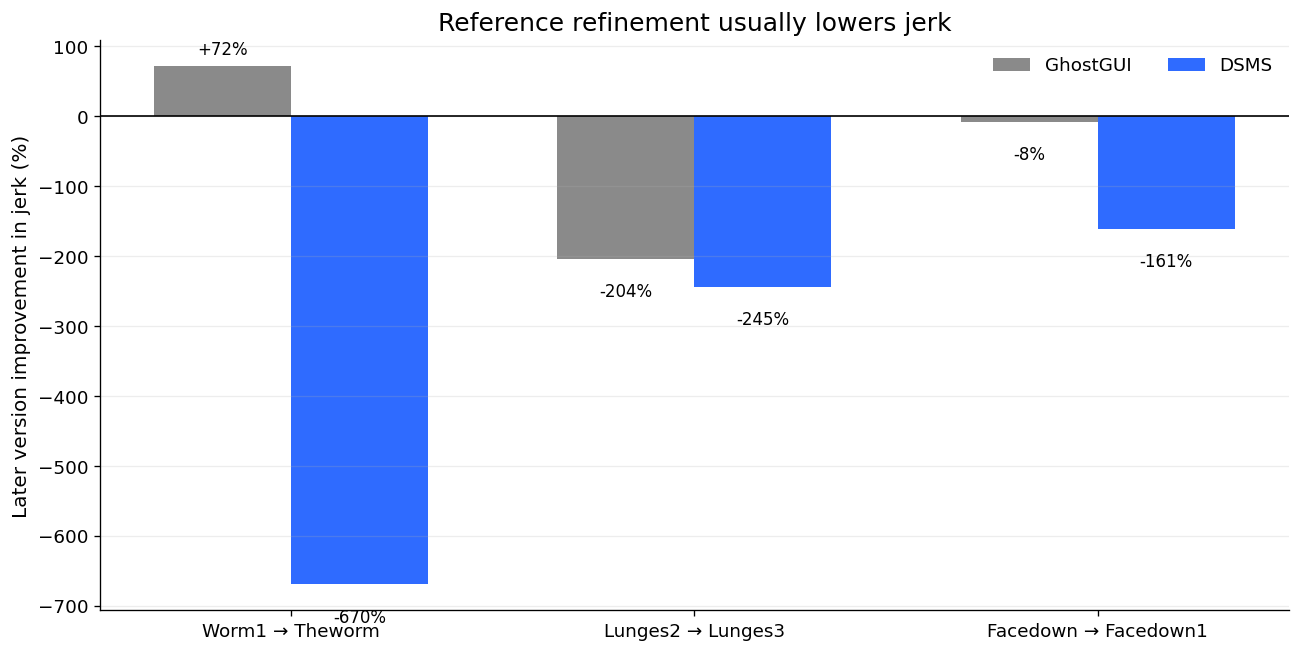

Saved: /home/nathan/Desktop/mjlab-trained/logs/dsms_analysis/ablation2_plots/01_reference_jerk_improvement.png


In [7]:

# ============================================================
# FIGURE 1 — REFERENCE JERK IMPROVEMENT
# Positive = later version has lower jerk.
# ============================================================

grouped_pair_plot(
    metric_key="reference_jerk_improvement_percent",
    ylabel="Later version improvement in jerk (%)",
    title="Reference refinement usually lowers jerk",
    filename="01_reference_jerk_improvement.png",
    percent=True,
)


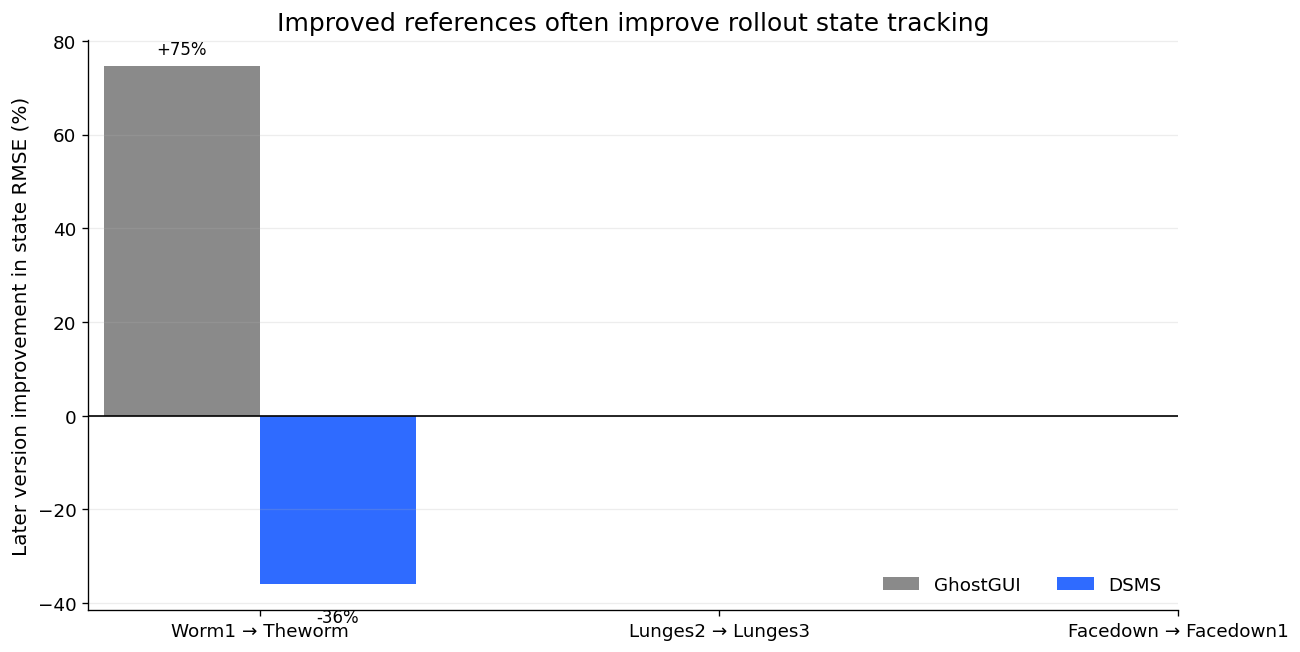

Saved: /home/nathan/Desktop/mjlab-trained/logs/dsms_analysis/ablation2_plots/02_trace_state_rmse_improvement.png


In [8]:

# ============================================================
# FIGURE 2 — CLEAN-ROLLOUT STATE RMSE IMPROVEMENT
# Positive = later version has lower state RMSE.
# ============================================================

grouped_pair_plot(
    metric_key="trace_state_rmse_improvement_percent",
    ylabel="Later version improvement in state RMSE (%)",
    title="Improved references often improve rollout state tracking",
    filename="02_trace_state_rmse_improvement.png",
    percent=True,
)


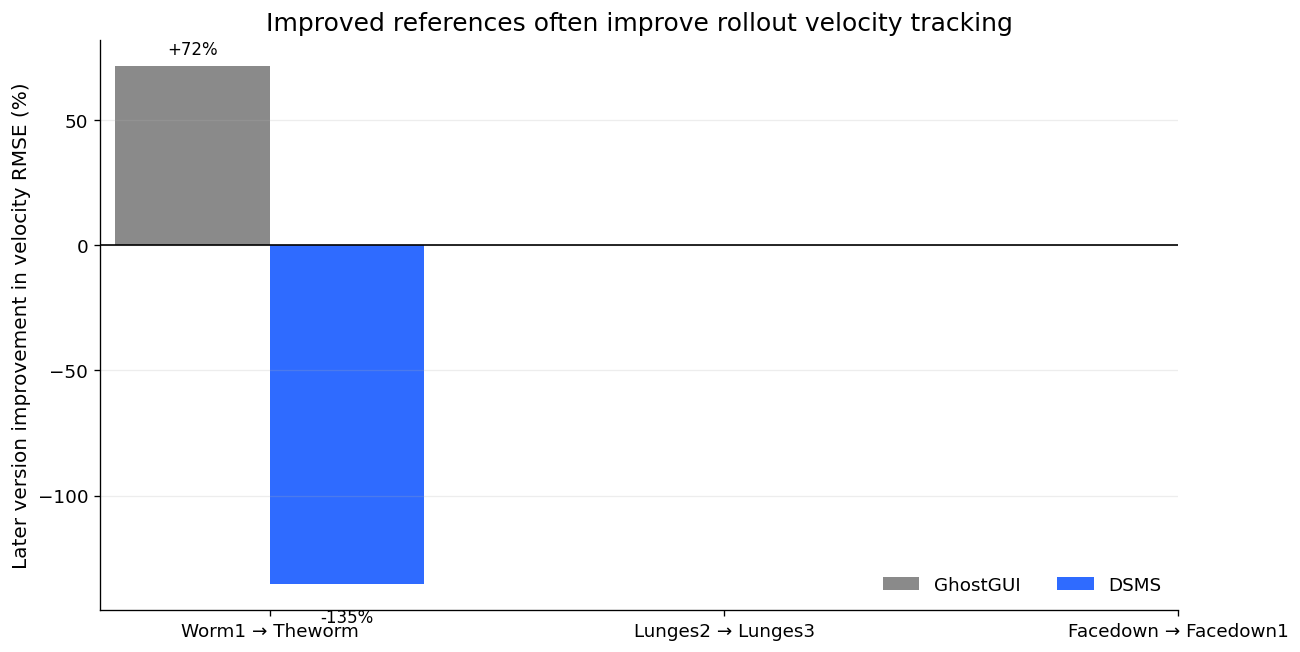

Saved: /home/nathan/Desktop/mjlab-trained/logs/dsms_analysis/ablation2_plots/03_trace_velocity_rmse_improvement.png


In [9]:

# ============================================================
# FIGURE 3 — CLEAN-ROLLOUT VELOCITY RMSE IMPROVEMENT
# Positive = later version has lower velocity RMSE.
# ============================================================

grouped_pair_plot(
    metric_key="trace_velocity_rmse_improvement_percent",
    ylabel="Later version improvement in velocity RMSE (%)",
    title="Improved references often improve rollout velocity tracking",
    filename="03_trace_velocity_rmse_improvement.png",
    percent=True,
)


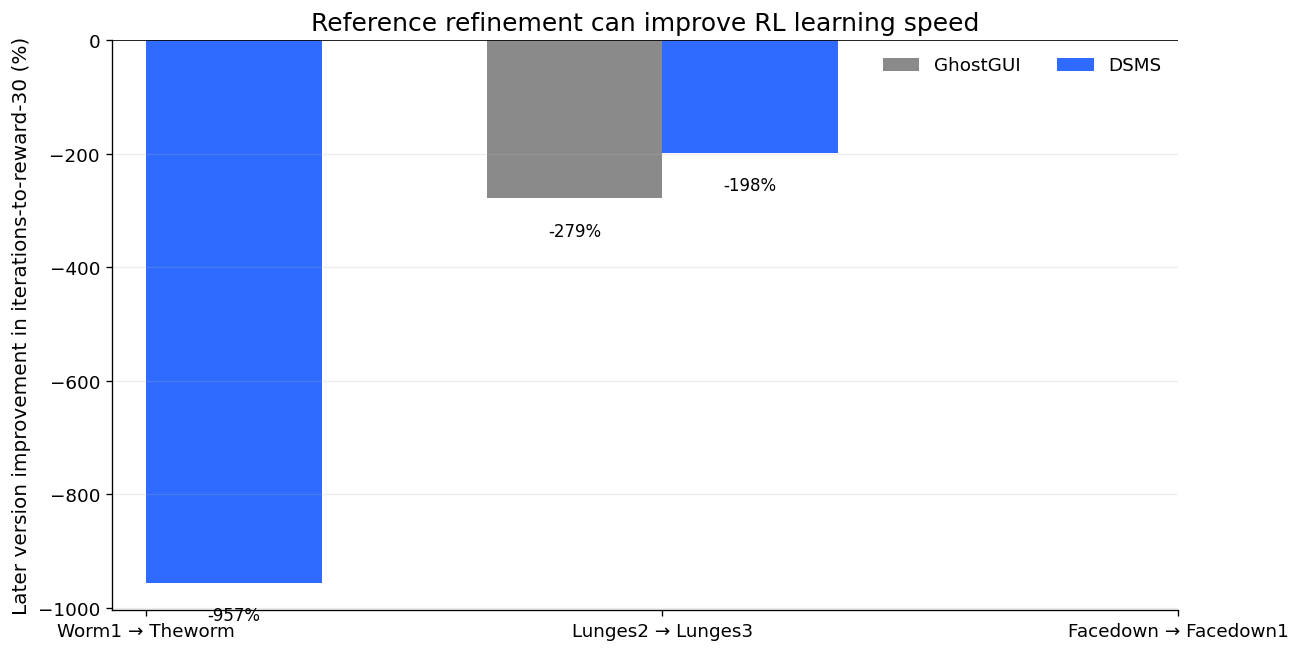

Saved: /home/nathan/Desktop/mjlab-trained/logs/dsms_analysis/ablation2_plots/04_learning_speed_improvement.png


In [10]:

# ============================================================
# FIGURE 4 — LEARNING SPEED IMPROVEMENT
# Positive = later version reached reward 30 in fewer iterations.
# Missing bars mean at least one run never reached reward 30.
# ============================================================

grouped_pair_plot(
    metric_key="learning_iterations_to_reward_30_improvement_percent",
    ylabel="Later version improvement in iterations-to-reward-30 (%)",
    title="Reference refinement can improve RL learning speed",
    filename="04_learning_speed_improvement.png",
    percent=True,
)


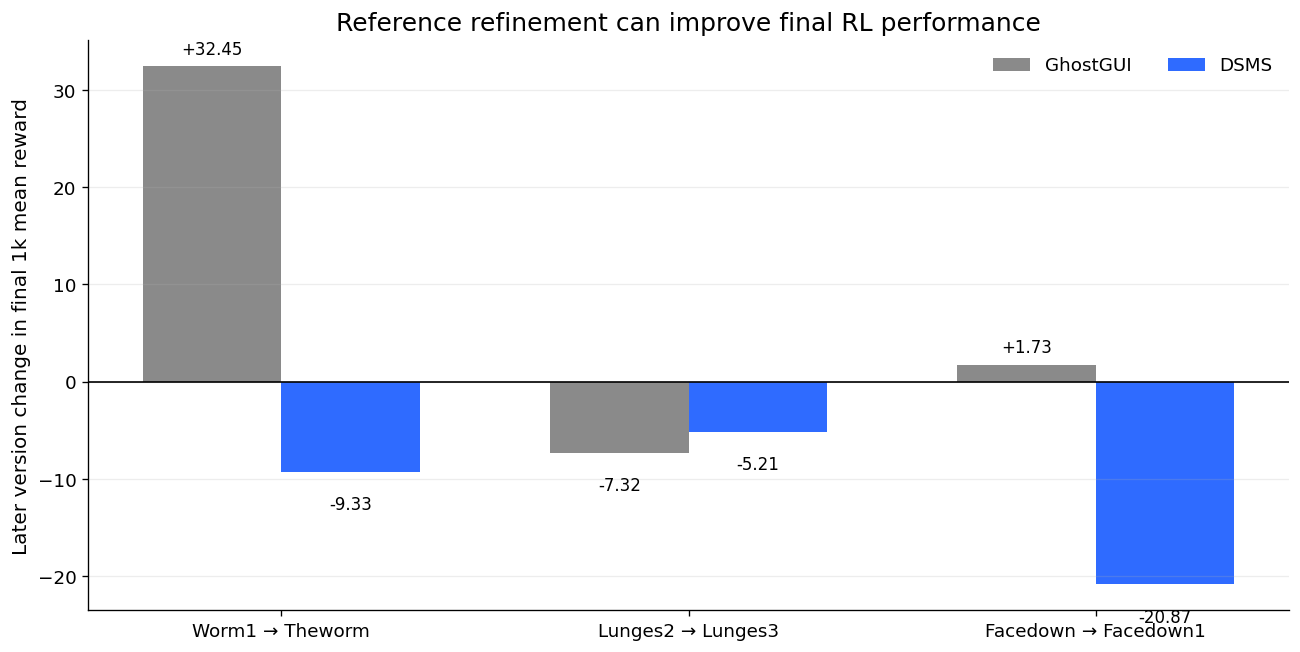

Saved: /home/nathan/Desktop/mjlab-trained/logs/dsms_analysis/ablation2_plots/05_final_reward_change.png


In [11]:

# ============================================================
# FIGURE 5 — FINAL REWARD CHANGE
# Positive = later version ended with higher final 1k mean reward.
# ============================================================

grouped_pair_plot(
    metric_key="learning_final_reward_delta",
    ylabel="Later version change in final 1k mean reward",
    title="Reference refinement can improve final RL performance",
    filename="05_final_reward_change.png",
    percent=False,
    delta=True,
)


In [12]:

# ============================================================
# AUTO-GENERATED TAKEAWAYS
# ============================================================

def verdict_from_value(v):
    if not is_finite(v):
        return "insufficient data"
    if v > 5:
        return "supports hypothesis"
    if v < -5:
        return "contradicts hypothesis"
    return "mixed / weak effect"

print("\n=== AUTO TAKEAWAYS ===")

for pair in PAIR_DEFS:
    print(f"\n{pair['label']}")

    for condition in CONDITIONS:
        row = next(
            r for r in summary_rows
            if r["label"] == pair["label"] and r["condition"] == condition
        )

        jerk_v = row["reference_jerk_improvement_percent"]
        state_v = row["trace_state_rmse_improvement_percent"]
        vel_v = row["trace_velocity_rmse_improvement_percent"]
        learn_v = row["learning_iterations_to_reward_30_improvement_percent"]
        reward_v = row["learning_final_reward_delta"]

        print(f"  {condition}:")
        print(f"    reference jerk: {verdict_from_value(jerk_v)} ({fmt(jerk_v, 1)}%)")
        print(f"    state RMSE:     {verdict_from_value(state_v)} ({fmt(state_v, 1)}%)")
        print(f"    velocity RMSE:  {verdict_from_value(vel_v)} ({fmt(vel_v, 1)}%)")
        print(f"    learning speed: {verdict_from_value(learn_v)} ({fmt(learn_v, 1)}%)")
        print(f"    final reward Δ: {fmt(reward_v, 2)}")



=== AUTO TAKEAWAYS ===

Worm1 → Theworm
  GhostGUI:
    reference jerk: supports hypothesis (71.7%)
    state RMSE:     supports hypothesis (74.6%)
    velocity RMSE:  supports hypothesis (71.6%)
    learning speed: insufficient data (NA%)
    final reward Δ: 32.45
  DSMS:
    reference jerk: contradicts hypothesis (-669.8%)
    state RMSE:     contradicts hypothesis (-36.0%)
    velocity RMSE:  contradicts hypothesis (-135.5%)
    learning speed: contradicts hypothesis (-956.7%)
    final reward Δ: -9.33

Lunges2 → Lunges3
  GhostGUI:
    reference jerk: contradicts hypothesis (-203.8%)
    state RMSE:     insufficient data (NA%)
    velocity RMSE:  insufficient data (NA%)
    learning speed: contradicts hypothesis (-278.8%)
    final reward Δ: -7.32
  DSMS:
    reference jerk: contradicts hypothesis (-244.6%)
    state RMSE:     insufficient data (NA%)
    velocity RMSE:  insufficient data (NA%)
    learning speed: contradicts hypothesis (-198.3%)
    final reward Δ: -5.21

Facedown

In [13]:

# ============================================================
# LIST GENERATED FILES
# ============================================================

print("\nGenerated files:")

for p in sorted(OUT_DIR.glob("*")):
    print(" -", p.name)



Generated files:
 - 01_reference_jerk_improvement.png
 - 02_trace_state_rmse_improvement.png
 - 03_trace_velocity_rmse_improvement.png
 - 04_learning_speed_improvement.png
 - 05_final_reward_change.png
 - ablation2_summary.csv
